# Brazilian E-Commerce Public Dataset by Olist

## Project Introduction

The goal of this project is to analyze customer behavior,
sales performance, delivery efficiency, and customer satisfaction.

## Data Loading

In [649]:
import os
os.listdir('../data')

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

За допомогою pandas завантажимо таблиці. 
За допомогою .head() подивимося як виглядають перші 5 рядків, як виглядають дані. 
За допомогою .shape перевіримо розмір таблиць (кількість рядків та колонок). 
За допомогою .info() подивимося типи даних кількість рядків, назви колонок, типи даних, скільки НЕ порожніх значень у кожній колонці, скільки пам'яті займає таблиця. Це допоможе зрозуміти зрозуміти чи правильно визначилися типи даних, чи є пропуски.
Метод .isnull().sum() показує кількість пропущених значень у кожній колонці.
пропущенні дані та дублікати.
Метод .duplicated().sum() показує кількість повністю однакових рядків.

In [650]:
import pandas as pd

orders = pd.read_csv("../data/olist_orders_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
category_translation = pd.read_csv("../data/product_category_name_translation.csv")

## Data Understanding

### Orders

In [651]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [652]:
orders.shape

(99441, 8)

In [653]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


В цій таблиці є 5 колонок з датами, але pandas їх прочитав як текст (object). Тобто одним із перших кроків cleaning буде трансформація їх у формат дати, щоб ми могли коректно працювати з датами: обчислювати різницю між ними, витягувати місяць, рік, день тижня та будувати часові тренди.

In [654]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

В таблиці orders присутні пропущені значення в колонках order_approved_at, order_delivered_carrier_date та order_delivered_customer_date.

In [655]:
orders.duplicated().sum()

np.int64(0)

### Customers

In [656]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [657]:
customers.shape

(99441, 5)

In [658]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [659]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [660]:
customers.duplicated().sum()

np.int64(0)

### Order_items

In [661]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [662]:
order_items.shape

(112650, 7)

In [663]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


Колонка shopping_limit_date містить дати, але pandas їх прочитав як текст (object).

In [664]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [665]:
order_items.duplicated().sum()

np.int64(0)

### Payments

In [666]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [667]:
payments.shape

(103886, 5)

In [668]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [669]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [670]:
payments.duplicated().sum()

np.int64(0)

### Reviews

In [671]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [672]:
reviews.shape

(99224, 7)

In [673]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


Колонки review_creation_date та review_answer_timestamp містять дату, але pandas прочитав як текст (object). Якщо я буду іх використовувати, то зміню на формат дати.

In [674]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Колонки review_comment_title та review_comment_message містять пропущені дані.

In [675]:
reviews.duplicated().sum()

np.int64(0)

### Products

In [676]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Назви категорії продуктів в колонці product_category_name написані іншою мовою. Тому їх краще замінити на англійську. Я це буду робити перед розрахунками.

In [677]:
products.shape

(32951, 9)

In [678]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [679]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [680]:
products.duplicated().sum()

np.int64(0)

### Category

In [681]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [682]:
category_translation.shape

(71, 2)

In [683]:
category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [684]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [685]:
category_translation.duplicated().sum()

np.int64(0)

## Data Cleaning
## Проаналізуємо пропуски

### order_delivered_customer
У колонці order_delivered_customer_date 2965 замовлень не мають дати доставки.
Перша гіпотеза: замовлення ще не доставлені або були скасовані.
Перевіримо:

In [686]:
orders.loc[
    orders['order_delivered_customer_date'].isnull(),
    'order_status'
].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [687]:
1107 + 619 + 609 + 314 + 301 + 8 + 5 + 2

2965

Для перевірки причин пропусків було проаналізовано статуси відповідних замовлень. Встановлено, що всі 2965 записів належать замовленням зі статусами shipped, processing, approved, invoiced, created, canceled, unavailable та delivered. Для цих замовлень присутні дати покупки, підтвердження оплати та передачі перевізнику, але відсутня дата доставки клієнту. Також є 8 замовлень зі статусом delivered, але не мають дати доставки, що може свідчити про незначні проблеми якості даних. Таким чином, переважна більшість пропусків є логічними та пов'язана з тим, що доставка не була завершена або замовлення було скасоване.

Я хочу переглянути ці 8 замовлень зі статусом delivered.

In [688]:
orders.loc[
    (orders['order_delivered_customer_date'].isnull()) &
    (orders['order_status'] == 'delivered')
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


Було додатково проаналізовано 8 замовлень зі статусом delivered, для яких відсутня дата доставки клієнту (order_delivered_customer_date). Перевірка показала, що для цих замовлень присутні дати покупки та підтвердження оплати, а для більшості також дата передачі перевізнику. Оскільки статус замовлення позначений як delivered, відсутність дати доставки, ймовірно, пов'язана з незначними проблемами якості даних або особливостями збору інформації. Через дуже малу кількість таких записів вони не мають суттєвого впливу на результати аналізу.

### order_delivered_carrier_date
В колонці order_delivered_carrier_date є пропущенні дати передачі перевізнику - 1783 замовлення.
Можливо замовлення скасували до відправки, або товар був unavailable.
Це теж можна дослідити.

In [689]:
carrier_missing = orders.loc[
    orders['order_delivered_carrier_date'].isnull(),
    'order_status'
].value_counts()

carrier_missing

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [690]:
carrier_missing.sum()

np.int64(1783)

In [691]:
orders.loc[
    (orders['order_delivered_carrier_date'].isnull()) &
    (orders['order_status'] == 'delivered')
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
73222,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaN,2017-11-20 19:44:47,2017-11-14 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00


У колонці order_delivered_carrier_date виявлено 1783 пропуски. Аналіз статусів показав, що більшість таких записів належить замовленням зі статусами unavailable, canceled, invoiced та processing, для яких відсутність дати передачі перевізнику є логічною. Лише 2 замовлення мають статус delivered. Детальний аналіз цих записів показав, що одне замовлення містить дату доставки клієнту, але не містить дату передачі перевізнику, а інше не містить жодної з дат доставки. Такі випадки є поодинокими та, ймовірно, пов'язані з проблемами якості даних. Загалом пропуски в цій колонці мають переважно бізнес-обґрунтований характер і не потребують заповнення.

### order_approved_at 
В цій колонці 160 замовлень не мають запису дат та часу підтвердження замовлення.

In [692]:
approved_at_missing = orders.loc[
    orders['order_approved_at'].isnull(),
    'order_status'
].value_counts()

approved_at_missing

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

Перевіримо ці 14 записів:

In [693]:
orders.loc[
    (orders['order_approved_at'].isnull()) &
    (orders['order_status'] == 'delivered')
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00
48401,7002a78c79c519ac54022d4f8a65e6e8,d5de688c321096d15508faae67a27051,delivered,2017-01-19 22:26:59,NaN,2017-01-27 11:08:05,2017-02-06 14:22:19,2017-03-16 00:00:00
61743,2eecb0d85f281280f79fa00f9cec1a95,a3d3c38e58b9d2dfb9207cab690b6310,delivered,2017-02-17 17:21:55,NaN,2017-02-22 11:42:51,2017-03-03 12:16:03,2017-03-20 00:00:00


Серед 160 пропусків у order_approved_at лише 14 замовлень мають статус delivered. Детальний аналіз показав, що для цих замовлень присутні дати передачі перевізнику та доставки клієнту, тому відсутність дати підтвердження замовлення є нелогічною з точки зору бізнес-процесу. Усі такі записи належать до початку 2017 року, що може свідчити про історичні проблеми якості даних або особливості міграції даних.

### Products table

В таблиці product колонки product_category_name, product_name_lenght, product_description_lenght та product_photos_qty мають однакову кількість пропущених даних - 610 рядків. Перевіримо, який вони становлять відсоток від загальної суми записів.

In [694]:
(610 / products.shape[0])*100

1.8512336499650999

Missing values становлять лише 1.85% від усіх записів, тому їхній вплив на результати аналізу, ймовірно, буде незначним.

### Reviews table
Колонка review_comment_title має 87656 пропущених значень. Колонка review_comment_message - 58247.

In [695]:
comment_title_missing = reviews.loc[
    reviews['review_comment_title'].isnull(),
    'review_score'
].value_counts().sort_index()

comment_title_missing

review_score
1     9551
2     2673
3     7355
4    17407
5    50670
Name: count, dtype: int64

In [696]:
comment_title_missing.sum()

np.int64(87656)

In [697]:
round(comment_title_missing / comment_title_missing.sum() * 100, 2)

review_score
1    10.90
2     3.05
3     8.39
4    19.86
5    57.81
Name: count, dtype: float64

In [698]:
comment_message_missing = reviews.loc[
    reviews['review_comment_message'].isnull(),
    'review_score'
].value_counts().sort_index()

comment_message_missing

review_score
1     2679
2     1006
3     4622
4    13166
5    36774
Name: count, dtype: int64

In [699]:
comment_message_missing.sum()

np.int64(58247)

In [700]:
round(comment_message_missing / comment_message_missing.sum() * 100, 2)

review_score
1     4.60
2     1.73
3     7.94
4    22.60
5    63.13
Name: count, dtype: float64

Аналіз показав, що для цих записів присутня оцінка (review_score), тобто клієнти залишили рейтинг, але не написали текстовий коментар. Більшість таких випадків припадає на оцінку 5 (понад 57%), що свідчить про те, що задоволені клієнти часто обмежуються виставленням оцінки без додаткового текстового відгуку. Тому ці пропуски є логічними і не потребують заповнення.

In [701]:
orders['order_id'].nunique()

99441

In [702]:
customers['customer_id'].nunique()

99441

In [703]:
customers['customer_unique_id'].nunique()

96096

In [704]:
products['product_id'].nunique()

32951

Таблиця orders містить 99 441 унікальне замовлення, тобто один рядок відповідає одному замовленню. У таблиці customers міститься 96 096 унікальних клієнтів, що менше за кількість записів клієнтів (99 441). Це свідчить про те, що частина клієнтів здійснювала повторні покупки. У датасеті також представлено 32 951 унікальний товар.  

Таблиця order_items має 112650 рядків, orders - 99441 рядків. Тобто, частина замовлень містить більше одного товару.

Таблиця payments має 103886 рядків, а таблиця orders - 99441 рядків. Тобто, одне замовлення могло оплачуватись кількома платежами.
Наприклад: кредитка + бонуси чи кілька платежів у розстрочку.

In [705]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Виявлено 3 записи not_defined. Переглянемо 

In [706]:
payments[
    payments['payment_type'] == 'not_defined'
]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


Подивимося статус цих замовлень:

In [707]:
orders[
    orders['order_id'].isin(
        payments[
            payments['payment_type'] == 'not_defined'
        ]['order_id']
    )
]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,2018-09-12 00:00:00
39919,4637ca194b6387e2d538dc89b124b0ee,a73c1f73f5772cf801434bf984b0b1a7,canceled,2018-09-03 14:14:25,NaN,NaN,NaN,2018-09-10 00:00:00
40235,c8c528189310eaa44a745b8d9d26908b,197a2a6a77da93f678ea0d379f21da0a,canceled,2018-08-28 20:05:14,NaN,NaN,NaN,2018-09-11 00:00:00


Further investigation showed that all of them were canceled orders with a payment value of zero and no approval or delivery information. These records likely represent orders that were canceled before payment processing and therefore do not affect the payment analysis.

Або українською: Додаткова перевірка показала, що всі вони належать до скасованих замовлень, мають суму платежу 0 та не містять інформації про підтвердження чи доставку. Імовірно, ці замовлення були скасовані до завершення процесу оплати, тому вони не впливають на результати аналізу способів оплати.

## Перетворення дати в формат datetime64.

In [708]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [709]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


## KPI Overview

In [710]:
kpi = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Total Revenue',
        'Average Order Value',
        'Median Order Value',
        'Repeat Purchase Rate',
        'On-Time Delivery Rate'
    ],
    'Value': [
        f"{orders['order_id'].nunique():,}",
        f"${payments['payment_value'].sum():,.2f}",
        f"${payments['payment_value'].mean():.2f}",
        f"${payments['payment_value'].median():.2f}",
        f"{repeat_rate:.2f}%",
        f"{on_time_rate:.2f}%"
    ]
})

kpi

,Metric,Value
0,Total Orders,"99,441"
1,Total Revenue,"$16,008,872.12"
2,Average Order Value,$154.10
3,Median Order Value,$100.00
4,Repeat Purchase Rate,3.12%
5,On-Time Delivery Rate,90.65%


## Question 1. How has revenue changed over time?

Об'єднаємо таблиці orders та payments через ключ - order_id.

In [711]:
sales = orders.merge(
    payments,
    on='order_id',
    how='inner'
)

Перевіряємо розмір новостворенної таблиці, бо в payments на одне замовлення може бути кілька записів. Нам треба переконатися, що ми правильно рахуємо revenue і не дублюємо замовлення (order_id).

In [712]:
sales.shape

(103886, 12)

Було: orders - 99,441 рядків, payments - 103,886 рядків.
Після merge: sales - 103,886 рядків
Це означає, що ми отримали по одному рядку на кожен запис із таблиці payments.
Тобто деякі замовлення мають кілька платежів, і це нормально.

In [713]:
sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,credit_card,3,179.12


Переглянемо за який період у нас дані.

In [714]:
sales['order_purchase_timestamp'].min()

Timestamp('2016-09-04 21:15:19')

In [715]:
sales['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

Спочатку створимо колонку місяця.

In [716]:
sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M')

In [717]:
sales.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'month'],
      dtype='object')

Потім порахуємо revenue по місяцях:

In [718]:
monthly_revenue = (
    sales
    .groupby('month')['payment_value']
    .sum()
    .reset_index()
)

monthly_revenue.head()

,month,payment_value
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01


### Line Chart — Monthly Revenue Trend

In [719]:
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

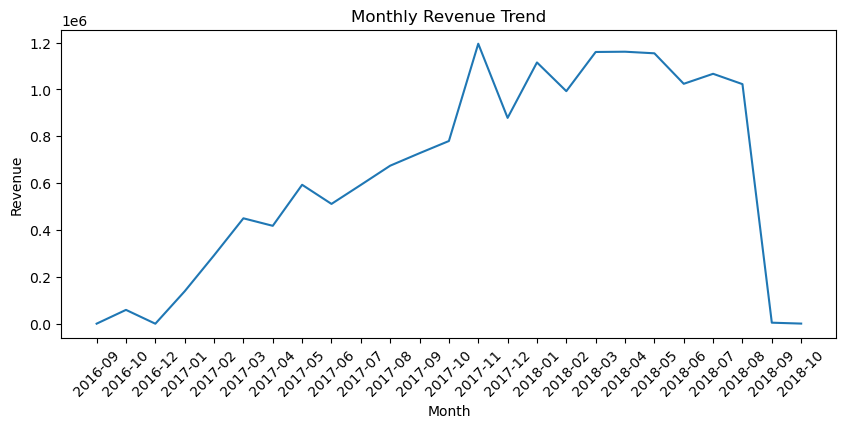

In [720]:
plt.figure(figsize=(10,4))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['payment_value']
)

plt.xticks(rotation=45)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

### Peak Revenue Months:

In [721]:
monthly_revenue.sort_values(
    'payment_value',
    ascending=False
).head()

,month,payment_value
13,2017-11,1194882.80
18,2018-04,1160785.48
17,2018-03,1159652.12
19,2018-05,1153982.15
15,2018-01,1115004.18


### Business Insight

Revenue demonstrates strong growth throughout 2017 and reaches its peak during late 2017 and early 2018.
The sharp decline observed in September and October 2018 is likely caused by incomplete data rather than an actual business downturn.

## Question 2. How has the number of orders changed over time?

In [722]:
monthly_orders = (
    sales
    .groupby('month')['order_id']
    .nunique()
    .reset_index()
)

monthly_orders.head()

,month,order_id
0,2016-09,3
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


### Line Chart — Monthly Orders Trend

In [723]:
monthly_orders['month'] = monthly_orders['month'].astype(str)

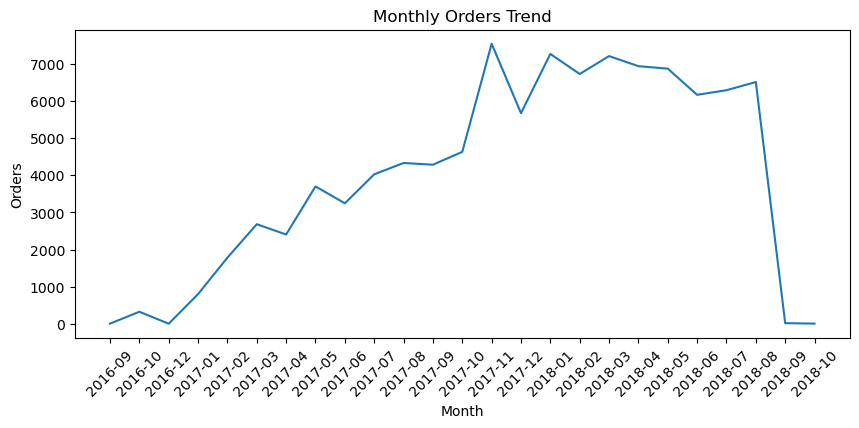

In [724]:
plt.figure(figsize=(10,4))

plt.plot(
    monthly_orders['month'],
    monthly_orders['order_id']
)

plt.xticks(rotation=45)

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Orders')

plt.show()

### Peak Order Months

In [725]:
monthly_orders.sort_values(
    'order_id',
    ascending=False
).head()

,month,order_id
13,2017-11,7544
15,2018-01,7269
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873


### Business Insight

November 2017 was the strongest month in terms of both revenue and number of orders. The similarity between revenue and order trends suggests that business growth was primarily driven by increased order volume rather than higher order values.

## Question 3. Which product categories generate the highest revenue?

Для цього нам треба з'єднати: order_items + products через: product_id і потім подивитися: product_category_name, price

In [726]:
product_sales = order_items.merge(
        products,
        on='product_id',
        how='left'
    )

In [727]:
product_sales.shape

(112650, 15)

In [728]:
product_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


Зараз назви категорій португальською. Тому об'єднаємо таблиці products та product_category_name_translation через поле product_category_name. Це дозволило замінити португальські назви категорій на англійські для подальшого аналізу.

In [729]:
product_sales = product_sales.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

In [730]:
product_sales.shape

(112650, 16)

In [731]:
product_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


Подивимося скільки у нас категорій:

Порахуємо revenue по категоріях:

In [732]:
category_revenue = (
    product_sales
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_revenue.head(10)

,product_category_name_english,price
0,health_beauty,1258681.34
1,watches_gifts,1205005.68
2,bed_bath_table,1036988.68
3,sports_leisure,988048.97
4,computers_accessories,911954.32
5,furniture_decor,729762.49
6,cool_stuff,635290.85
7,housewares,632248.66
8,auto,592720.11
9,garden_tools,485256.46


### Chart — Top 10 Categories by Revenue

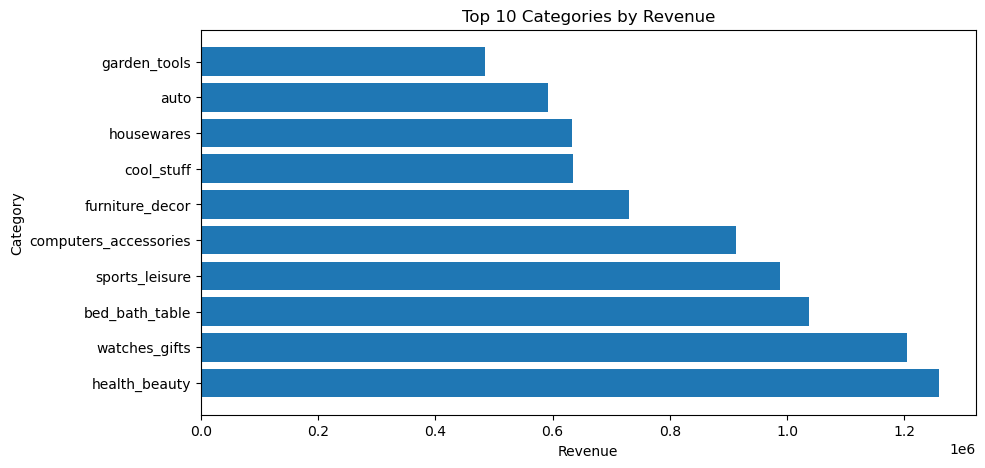

In [733]:
top10 = category_revenue.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10['product_category_name_english'],
    top10['price']
)

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Category')

plt.show()

Які категорії продаються найчастіше?

In [734]:
category_orders = (
    product_sales
    .groupby('product_category_name_english')['order_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

category_orders.head(10)

,product_category_name_english,order_id
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
5,housewares,6964
6,watches_gifts,5991
7,telephony,4545
8,garden_tools,4347
9,auto,4235


Чи справді Watches & Gifts мають вищу середню ціну?

In [735]:
category_avg_price = (
    product_sales
    .groupby('product_category_name_english')['price']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_avg_price.head(10)

,product_category_name_english,price
0,computers,1098.340542
1,small_appliances_home_oven_and_coffee,624.285658
2,home_appliances_2,476.124958
3,agro_industry_and_commerce,342.124858
4,musical_instruments,281.616000
5,small_appliances,280.778468
6,fixed_telephony,225.693182
7,construction_tools_safety,208.992371
8,watches_gifts,201.135984
9,air_conditioning,185.269226


Watches & Gifts НЕ є найдорожчою категорією. Вона займає 9 місце за середньою ціною. Високий Revenue цієї категорії пояснюється не тільки ціною.
Швидше за все комбінацією: відносно висока ціна та достатньо великий обсяг продажів.

In [736]:
product_sales[
    product_sales['product_category_name_english'] == 'computers'
]['price'].describe()

count     203.000000
mean     1098.340542
std       668.513798
min        34.500000
25%       650.000000
50%      1100.000000
75%      1340.000000
max      6729.000000
Name: price, dtype: float64

Висока середня ціна є характерною для більшості товарів цієї категорії, а не результатом кількох аутлайерів. Середня ціна та медіана майже однакові.

The Computers category has the highest average selling price (≈1098), but it accounts for a relatively small number of transactions (203 sales). In contrast, categories such as Health & Beauty generate higher total revenue through significantly larger sales volumes.

українською:
Категорія Computers має найвищу середню ціну продажу (≈1098), але на неї припадає відносно невелика кількість транзакцій (203 продажі). Натомість такі категорії, як Health & Beauty, генерують вищий загальний дохід завдяки значно більшим обсягам продажів.

### Business Insight
Bed Bath & Table products are the most frequently purchased category, while Health & Beauty and Watches & Gifts generate the highest revenue. This suggests that some categories drive revenue through higher prices, while others rely on high sales volume.

українською:
Товари Bed Bath & Table є категорією, яку купують найчастіше, тоді як товари Health & Beauty та Watches & Gifts генерують найбільший дохід. Це свідчить про те, що деякі категорії отримують дохід за рахунок вищих цін, тоді як інші покладаються на високий обсяг продажів.

## Question 4. Which product categories have high sales but low customer ratings?

Ми хочемо знайти категорії, які добре продаються, але отримують низькі оцінки.

In [737]:
category_reviews = (
    reviews
    .merge(
        orders[['order_id']],
        on='order_id',
        how='left'
    )
    .merge(
        order_items[['order_id', 'product_id']],
        on='order_id',
        how='left'
    )
    .merge(
        products[['product_id', 'product_category_name']],
        on='product_id',
        how='left'
    )
    .merge(
        category_translation,
        on='product_category_name',
        how='left'
    )
)

In [738]:
category_rating = (
    category_reviews
    .groupby('product_category_name_english')
    .agg(
        avg_rating=('review_score', 'mean'),
        reviews_count=('review_score', 'count')
    )
    .sort_values('avg_rating', ascending=False)
    .reset_index()
)

In [739]:
category_rating_filtered = (
    category_rating[
        category_rating['reviews_count'] >= 100
    ]
)

Об'єднаємо таблиці revenue та rating:

In [740]:
category_performance = category_revenue.merge(
    category_rating_filtered,
    on='product_category_name_english',
    how='inner'
)

Подивимося найприбутковіші категорії:

In [741]:
category_performance.sort_values(
    'price',
    ascending=False
).head(10)

,product_category_name_english,price,avg_rating,reviews_count
0,health_beauty,1258681.34,4.142768,9645
1,watches_gifts,1205005.68,4.019160,5950
2,bed_bath_table,1036988.68,3.895663,11137
3,sports_leisure,988048.97,4.107986,8640
4,computers_accessories,911954.32,3.930819,7849
5,furniture_decor,729762.49,3.903493,8331
6,cool_stuff,635290.85,4.146341,3772
7,housewares,632248.66,4.055019,6943
8,auto,592720.11,4.065512,4213
9,garden_tools,485256.46,4.042735,4329


Знайдемо високі продажі + низький рейтинг.
Спочатку подивимося медіани:

In [742]:
category_performance['price'].median()

98202.93

In [743]:
round(category_performance['avg_rating'].median(), 2)

4.05

In [744]:
high_sales_low_rating = category_performance[
    (category_performance['price'] >
     category_performance['price'].median())
    &
    (category_performance['avg_rating'] <
     category_performance['avg_rating'].median())
]

high_sales_low_rating.sort_values(
    'price',
    ascending=False
)

,product_category_name_english,price,avg_rating,reviews_count
1,watches_gifts,1205005.68,4.019160,5950
2,bed_bath_table,1036988.68,3.895663,11137
4,computers_accessories,911954.32,3.930819,7849
5,furniture_decor,729762.49,3.903493,8331
9,garden_tools,485256.46,4.042735,4329
11,baby,411764.89,4.011811,3048
13,telephony,323667.53,3.946867,4517
14,office_furniture,273960.70,3.493183,1687
20,electronics,160246.74,4.037468,2749
21,consoles_games,157465.22,4.023070,1127


### Chart - Revenue vs Customer Rating by Category

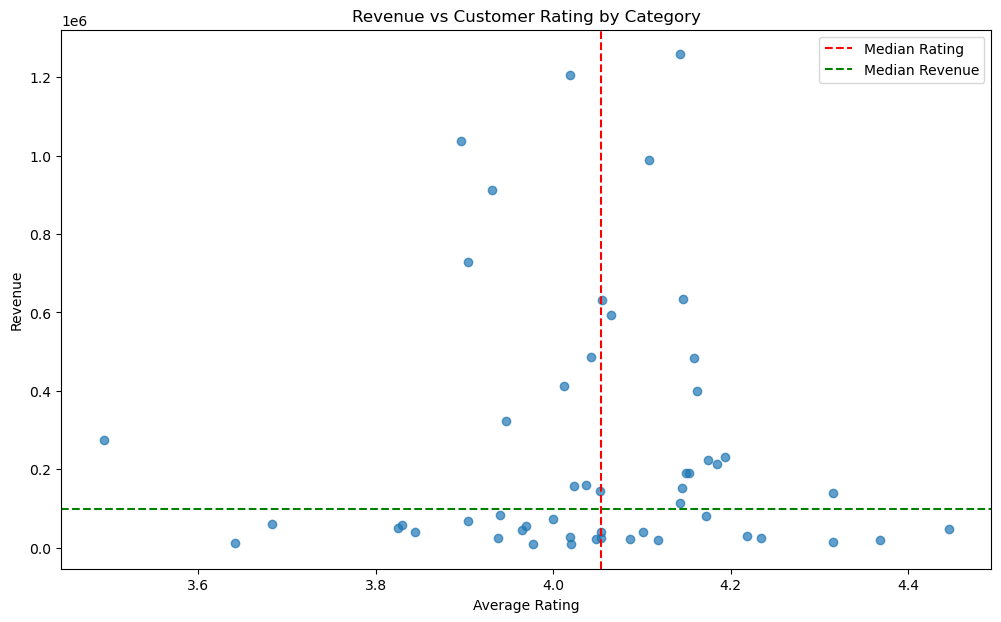

In [745]:
plt.figure(figsize=(12,7))

plt.scatter(
    category_performance['avg_rating'],
    category_performance['price'],
    alpha=0.7
)

plt.axvline(
    category_performance['avg_rating'].median(),
    color='red',
    linestyle='--',
    label='Median Rating'
)

plt.axhline(
    category_performance['price'].median(),
    color='green',
    linestyle='--',
    label='Median Revenue'
)

plt.xlabel('Average Rating')
plt.ylabel('Revenue')
plt.title('Revenue vs Customer Rating by Category')

plt.legend()

plt.show()

Більшість категорій мають рейтинг близько 4.0–4.2 Тобто загалом клієнти досить задоволені покупками.

У верхній правій частині графіка знаходяться категорії з високим revenue та високим рейтингом. Це найсильніші категорії бізнесу.
У верхній лівій частині знаходяться категорії, які добре продаються, але отримують нижчі оцінки клієнтів. Саме вони створюють найбільшу можливість для покращення бізнес-результатів.

The most notable categories requiring attention are Watches & Gifts, Bed Bath Table, Computers Accessories, and Furniture Decor, as they combine high revenue with below-median customer ratings.

українською:
Найбільш помітними категоріями, що потребують уваги, є Watches & Gifts, Bed Bath Table, Computers Accessories та Furniture Decor, оскільки вони поєднують високий дохід з оцінками клієнтів нижче середнього.

### Business Insight

Most product categories receive customer ratings around 4.0, indicating generally positive customer satisfaction. However, several high-revenue categories have below-average ratings, suggesting that strong sales do not always translate into positive customer experiences. Improving customer satisfaction in these high-performing categories could increase customer loyalty, encourage repeat purchases, and generate additional revenue growth.

Українською:
Більшість категорій мають середній рейтинг близько 4.0, що свідчить про загалом позитивний клієнтський досвід. Водночас деякі категорії з високими продажами отримують нижчі оцінки від покупців. Це означає, що значний обсяг продажів не завжди супроводжується високим рівнем задоволеності клієнтів. Покращення якості товарів або сервісу в цих категоріях може підвищити лояльність клієнтів, збільшити частку повторних покупок та сприяти подальшому зростанню доходу.

## Question 5. Does delivery performance affect customer satisfaction?

Об'єднаємо Orders + Reviews

In [746]:
delivery_reviews = orders.merge(
    reviews,
    on='order_id',
    how='inner'
)

delivery_reviews.shape

(99224, 14)

Створюємо показник запізнення:

In [747]:
delivery_reviews['delivery_delay_days'] = (
    delivery_reviews['order_delivered_customer_date']
    - delivery_reviews['order_estimated_delivery_date']
).dt.days

In [748]:
delivery_reviews.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'delivery_delay_days'],
      dtype='object')

Подивимось статистику:

In [749]:
round(delivery_reviews['delivery_delay_days'].describe(), 2)

count    96359.00
mean       -11.92
std         10.11
min       -147.00
25%        -17.00
50%        -12.00
75%         -7.00
max        188.00
Name: delivery_delay_days, dtype: float64

У середньому замовлення доставлялися на 12 днів РАНІШЕ від обіцяної дати.
25% замовлень доставляли мінімум на 17 днів раніше. Половину замовлень доставляли мінімум на 12 днів раніше. Навіть 75% замовлень доставляли мінімум на 7 днів раніше. Це дуже хороший показник для бізнесу.

Розіб'ємо на дві групи: Late та On Time/ Early

In [750]:
delivery_reviews['delivery_status'] = (
    delivery_reviews['delivery_delay_days']
    .apply(
        lambda x:
        'Late' if x > 0
        else 'On Time / Early'
    )
)

Метод apply() застосовує функцію до кожного значення в колонці. У цьому випадку lambda-функція перевіряє, чи затримка доставки більша за нуль. Якщо так — замовлення позначається як Late, інакше як On Time / Early. Результат зберігається в новій колонці delivery_status.

Перевіримо нашу головну гіпотезу, чи клієнти, які отримали замовлення із запізненням, ставлять нижчі оцінки.

In [751]:
round(delivery_reviews.groupby(
    'delivery_status'
)['review_score'].mean(), 2)

delivery_status
Late               2.27
On Time / Early    4.21
Name: review_score, dtype: float64

### Chart - Average Review Score by Delivery Status

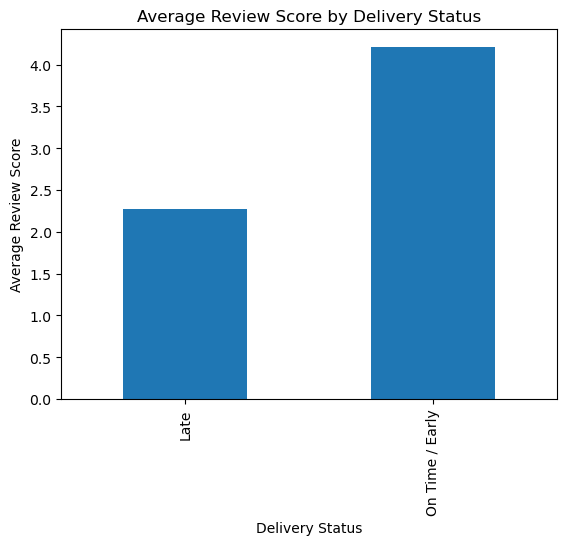

In [752]:
delivery_reviews.groupby(
    'delivery_status'
)['review_score'].mean().plot(
    kind='bar'
)

plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')

plt.show()

### Business Insight

Delivery performance has a major impact on customer satisfaction. Orders delivered on time or ahead of schedule received an average rating of 4.21, while late deliveries received only 2.27. This suggests that delivery reliability is one of the strongest drivers of customer satisfaction.

Українською:
Своєчасна доставка суттєво впливає на задоволеність клієнтів. Замовлення, доставлені вчасно або раніше, отримували середню оцінку 4.21, тоді як запізнілі замовлення — лише 2.27. Це свідчить про те, що якість логістики є одним із ключових факторів клієнтського досвіду.

*Якщо запізнення сильно впливає на рейтинг, то треба покращувати логістику, змінювати перевізників, коригувати обіцяні терміни доставки.

## Question 6. What percentage of orders are delivered on time?

Створимо окрему колонку де вказана кількість доставленних вчасно або раніше прогнозованої дати замовлень.

In [753]:
delivery_reviews['on_time'] = (
    delivery_reviews['delivery_delay_days'] <= 0
)

In [754]:
delivery_reviews.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'delivery_delay_days', 'delivery_status',
       'on_time'],
      dtype='object')

Порахуємо % доставлених вчасно/раніше:

In [755]:
delivery_rate = (
    delivery_reviews['on_time']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

delivery_rate.columns = ['on_time', 'percentage']

delivery_rate

,on_time,percentage
0,True,90.65
1,False,9.35


### Chart - On-Time Delivery Rate

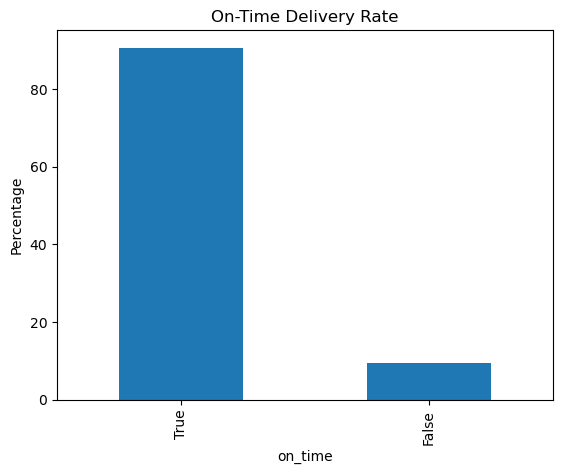

In [756]:
delivery_reviews['on_time'].value_counts(
    normalize=True
).mul(100).plot(
    kind='bar'
)

plt.title('On-Time Delivery Rate')
plt.ylabel('Percentage')
plt.show()

### Business Insight

Approximately 90.7% of all orders were delivered on or before the estimated delivery date, while only 9.3% were delivered late. This indicates strong logistics performance and a reliable delivery process. Maintaining a high on-time delivery rate is important because previous analysis showed that late deliveries are associated with significantly lower customer review scores.

українською:

Близько 90.7% усіх замовлень були доставлені вчасно або раніше прогнозованої дати доставки, тоді як лише 9.3% замовлень були доставлені із запізненням. Це свідчить про високий рівень ефективності логістичних процесів компанії. Підтримання високого відсотка вчасних доставок є важливим, оскільки попередній аналіз показав, що затримки доставки суттєво знижують задоволеність клієнтів та їхні оцінки замовлень.

## Question 7. What payment methods do customers prefer?

In [757]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [758]:
round(payments['payment_type'].value_counts(normalize=True) * 100, 2)

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

Кредитна картка абсолютно домінує. Майже 74% усіх платежів.

In [759]:
payment_analysis = (
    payments
    .groupby('payment_type')
    .agg(
        transactions=('order_id', 'count'),
        revenue=('payment_value', 'sum'),
        avg_payment=('payment_value', 'mean')
    )
    .sort_values('revenue', ascending=False)
)

payment_analysis

,transactions,revenue,avg_payment
payment_type,,,
credit_card,76795,12542084.19,163.319021
boleto,19784,2869361.27,145.034435
voucher,5775,379436.87,65.703354
debit_card,1529,217989.79,142.570170
not_defined,3,0.00,0.000000


 ### Chart - Payment Method Distribution

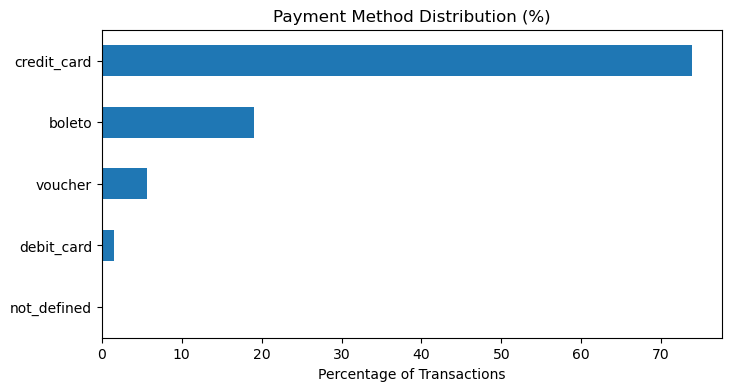

In [760]:
payment_pct = (
    payments['payment_type']
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

payment_pct.sort_values().plot(
    kind='barh',
    figsize=(8,4)
)

plt.title('Payment Method Distribution (%)')
plt.xlabel('Percentage of Transactions')
plt.ylabel('')
plt.show()

### Business Insight

Credit cards are not only the most frequently used payment method (73.9% of transactions) but also generate the highest revenue. Customers using credit cards spend an average of 163.32 per transaction, compared to 145.03 for boleto and 142.57 for debit card payments. Voucher payments are associated with significantly smaller purchases, averaging only 65.70 per transaction.

## Question 8. How many customers make repeat purchases?

Об'єднаємо orders та customers.

In [761]:
customer_orders = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

In [762]:
customer_orders.shape

(99441, 12)

Потім рахуємо кількість замовлень на клієнта:

In [763]:
customer_frequency = (
    customer_orders
    .groupby('customer_unique_id')['order_id']
    .count()
    .reset_index()
)

In [764]:
round(customer_frequency['order_id'].describe(), 2)

count    96096.00
mean         1.03
std          0.21
min          1.00
25%          1.00
50%          1.00
75%          1.00
max         17.00
Name: order_id, dtype: float64

Типовий клієнт зробив лише 1 замовлення. Принаймні 75% клієнтів зробили лише одне замовлення.

In [765]:
repeat_customers = (
    customer_frequency['order_id'] > 1
).sum()

repeat_customers

np.int64(2997)

Яка частка клієнтів повертається за повторною покупкою?

In [766]:
total_customers = customer_frequency.shape[0]

repeat_rate = (
    repeat_customers
    / total_customers
    * 100
)

repeat_rate.round(2)

np.float64(3.12)

Лише близько 3.1% клієнтів повернулися за повторною покупкою.

In [767]:
customer_frequency.sort_values(
    'order_id',
    ascending=False
).head(10)

,customer_unique_id,order_id
52973,8d50f5eadf50201ccdcedfb9e2ac8455,17
23472,3e43e6105506432c953e165fb2acf44c,9
37797,6469f99c1f9dfae7733b25662e7f1782,7
76082,ca77025e7201e3b30c44b472ff346268,7
10354,1b6c7548a2a1f9037c1fd3ddfed95f33,7
7175,12f5d6e1cbf93dafd9dcc19095df0b3d,6
83540,de34b16117594161a6a89c50b289d35a,6
37585,63cfc61cee11cbe306bff5857d00bfe4,6
90451,f0e310a6839dce9de1638e0fe5ab282a,6
27043,47c1a3033b8b77b3ab6e109eb4d5fdf3,6


У датасеті присутні повторні покупці, що свідчить про певний рівень утримання клієнтів (customer retention). Найактивніший клієнт здійснив 17 замовлень.

### Business Insight

The vast majority of customers placed only one order, while a small percentage of customers returned repeatedly. This indicates a loyal customer base, although the bulk of buyers make one-time purchases.

українською:
Переважна більшість клієнтів здійснила лише одне замовлення, тоді як невелика частка клієнтів поверталася повторно. Це свідчить про наявність лояльної клієнтської бази, хоча основний обсяг покупців здійснює разові покупки.

## Question 9. Which states generate the highest revenue?

Створимо зведену таблицю

In [768]:
state_revenue = (
    orders
    .merge(
        customers[['customer_id', 'customer_state']],
        on='customer_id',
        how='left'
    )
    .merge(
        payments[['order_id', 'payment_value']],
        on='order_id',
        how='left'
    )
)

state_revenue.shape

(103887, 10)

Подивимося Revenue по штатах:

In [769]:
revenue_by_state = (
    state_revenue
    .groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_state.head(10)

,customer_state,payment_value
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


Кількість замовлень по штатах:

In [770]:
orders_by_state = (
    state_revenue
    .groupby('customer_state')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

orders_by_state.head(10)

,customer_state,order_id
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


Рейтинг Revenue і Orders майже однововий. Revenue росте переважно через більшу кількість замовлень, а не через те, що в якомусь штаті люди купують значно дорожчі товари.

### Chart — Top 10 States by Revenue

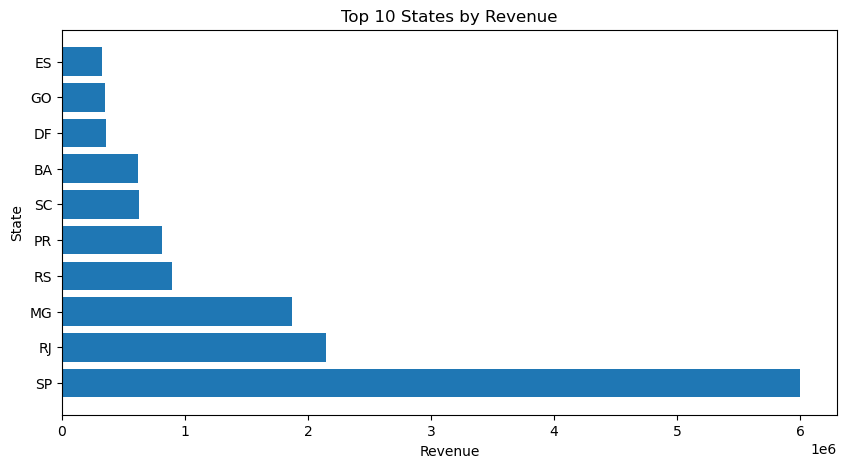

In [771]:
top10_states = revenue_by_state.head(10)

plt.figure(figsize=(10,5))

plt.barh(
    top10_states['customer_state'],
    top10_states['payment_value']
)

plt.title('Top 10 States by Revenue')
plt.xlabel('Revenue')
plt.ylabel('State')

plt.show()

### Business Insight
São Paulo (SP) is the dominant market, generating nearly 6 million in revenue and accounting for the largest share of orders. The business appears to be highly concentrated in a single state.

українською:
São Paulo (SP) є домінуючим ринком, генеруючи майже 6 мільйонів доходів і займаючи найбільшу частку замовлень. Бізнес, схоже, сильно зосереджений в одному штаті.

## Question 10. Which product categories receive the highest and lowest customer ratings?

In [772]:
category_rating_filtered.sort_values(
    'avg_rating',
    ascending=False
).head(10)

,product_category_name_english,avg_rating,reviews_count
2,books_general_interest,4.446266,549
6,books_technical,4.368421,266
7,food_drink,4.315412,279
8,luggage_accessories,4.315257,1088
11,fashion_shoes,4.233716,261
12,food,4.218182,495
15,stationery,4.193857,2507
16,pet_shop,4.185147,1939
17,computers,4.175000,200
18,home_appliances,4.172457,806


In [773]:
category_rating_filtered.sort_values(
    'avg_rating',
    ascending=False
).tail(10)

,product_category_name_english,avg_rating,reviews_count
55,computers_accessories,3.930819,7849
56,furniture_living_room,3.904382,502
57,furniture_decor,3.903493,8331
58,bed_bath_table,3.895663,11137
59,construction_tools_safety,3.844560,193
60,home_confort,3.829885,435
61,audio,3.825485,361
65,fixed_telephony,3.683206,262
66,fashion_male_clothing,3.641221,131
68,office_furniture,3.493183,1687


### Business Insight
Categories such as books, food products, and travel accessories received the highest average customer ratings, indicating strong customer satisfaction. In contrast, the office furniture category showed the lowest average rating despite a large number of reviews. This suggests potential issues with product quality, delivery performance, or customer expectations. Further investigation is recommended to identify the root causes of customer dissatisfaction in this category.

українською:
Такі категорії, як книги, продукти харчування та аксесуари для подорожей, отримали найвищі середні оцінки клієнтів, що свідчить про високу задоволеність клієнтів. Натомість, категорія офісних меблів показала найнижчий середній рейтинг, незважаючи на велику кількість відгуків. Це говорить про потенційні проблеми з якістю продукції, доставкою або очікуваннями клієнтів. Рекомендується подальше дослідження, щоб визначити першопричини невдоволення клієнтів у цій категорії.

## Executive Summary

This analysis examined customer purchasing behavior, payment preferences, product performance, delivery efficiency, and customer satisfaction using the Olist e-commerce dataset.

The results show that both revenue and order volume increased significantly over the analyzed period, indicating strong business growth. Product categories such as Health & Beauty, Watches & Gifts, and Bed Bath Table generated the highest revenue. However, some of these high-performing categories received below-average customer ratings, suggesting opportunities to improve customer experience.

Delivery performance was found to have a strong impact on customer satisfaction. Orders delivered on time or earlier received substantially higher review scores than delayed orders. Additionally, approximately 90.7% of orders were delivered on time, demonstrating effective logistics operations.

Customer retention remains a challenge, as only about 3.1% of customers made repeat purchases. This suggests that while the company successfully attracts new customers, there may be opportunities to improve loyalty and encourage repeat buying behavior.

Overall, the analysis highlights the importance of maintaining delivery performance, improving customer satisfaction in key product categories, and developing retention strategies to support long-term growth.


## Recommendations

1. Improve customer experience in high-revenue but lower-rated categories, particularly Watches & Gifts, Bed Bath Table, Computers & Accessories, and Furniture Decor.

2. Continue investing in logistics performance to maintain the high on-time delivery rate, as delivery delays are strongly associated with lower customer satisfaction.

3. Investigate the root causes of lower ratings in underperforming categories by analyzing customer review comments and product quality issues.

4. Develop customer retention initiatives such as loyalty programs, personalized offers, and post-purchase engagement campaigns to increase repeat purchases.

5. Focus marketing efforts on top-performing product categories and high-revenue states, where the company already demonstrates strong demand.

6. Monitor customer satisfaction metrics alongside revenue metrics to ensure that business growth is supported by a positive customer experience.
